In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')

# %cd /content/drive/MyDrive/Colab Notebooks/Kaggle Tubular Playground Series/S4E8 Binary Prediction of Poisonous Mushrooms/

Mounted at /content/drive/
/content/drive/MyDrive/Colab Notebooks/Kaggle Tubular Playground Series/S4E8 Binary Prediction of Poisonous Mushrooms


In [97]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.compose import ColumnTransformer 
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import eda_util

In [3]:
RANDOM_STATE = 1048576
TARGET = 'y'

# Data Loading

In [4]:
train_csv = pd.read_csv('datasets/train_split.csv', index_col=0)
val_csv = pd.read_csv('datasets/val_split.csv', index_col=0)
test_csv = pd.read_csv('datasets/test_split.csv', index_col=0)

In [5]:
display(train_csv.head())
display(val_csv.head())
display(test_csv.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
107791,45,management,married,tertiary,no,6771,no,no,cellular,22,aug,234,1,-1,0,unknown,1
408330,50,blue-collar,married,primary,no,705,no,no,unknown,17,jun,144,2,-1,0,unknown,0
250766,58,retired,married,secondary,no,1386,no,yes,cellular,8,jul,203,1,-1,0,unknown,0
630459,30,blue-collar,single,secondary,no,799,yes,no,cellular,11,may,239,1,-1,0,unknown,0
291674,32,admin.,single,tertiary,no,953,yes,no,cellular,16,apr,193,1,-1,0,unknown,0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
29160,33,technician,married,secondary,no,1625,no,no,cellular,21,aug,85,6,-1,0,unknown,0
624277,50,management,married,tertiary,no,0,yes,no,cellular,24,jul,112,1,-1,0,unknown,0
304510,38,management,married,tertiary,no,563,yes,yes,cellular,18,nov,110,2,123,1,failure,0
194526,65,retired,divorced,primary,no,3428,no,no,cellular,21,oct,212,2,-1,0,unknown,1
341449,36,admin.,single,secondary,yes,-185,yes,yes,unknown,6,jun,12,12,-1,0,unknown,0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
367679,39,blue-collar,married,secondary,no,794,no,no,unknown,11,jun,67,2,-1,0,unknown,0
234998,47,self-employed,married,tertiary,no,948,no,no,cellular,4,feb,156,1,-1,0,unknown,0
147362,57,management,married,tertiary,no,11891,no,no,unknown,19,jun,541,1,-1,0,unknown,0
151891,31,admin.,single,tertiary,no,4388,no,no,telephone,29,jul,92,2,-1,0,unknown,0
497703,41,blue-collar,married,secondary,no,2552,yes,no,cellular,8,may,1064,1,-1,0,unknown,1


In [6]:
print(f'Training set shape: {train_csv.shape}, Validation set shape: {val_csv.shape}, Test set shape: {test_csv.shape}')
eda_util.DataImport.datasplit_info(train_csv, val_csv, test_csv)

Training set shape: (600000, 17), Validation set shape: (75000, 17), Test set shape: (75000, 17)


,Column,Train Null Count,Val Null Count,Test Null Count,Dtype
0,age,0,0,0,int64
1,job,0,0,0,object
2,marital,0,0,0,object
3,education,0,0,0,object
4,default,0,0,0,object
5,balance,0,0,0,int64
6,housing,0,0,0,object
7,loan,0,0,0,object
8,contact,0,0,0,object
9,day,0,0,0,int64


# Feature-Target Split

In [7]:
X_train, y_train = train_csv.drop(columns=[TARGET]), train_csv[TARGET]
X_val, y_val = val_csv.drop(columns=[TARGET]), val_csv[TARGET]
X_test, y_test = test_csv.drop(columns=[TARGET]), test_csv[TARGET]
print(f'X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}')

X_train shape: (600000, 16), X_val shape: (75000, 16), X_test shape: (75000, 16)


# Preprocessing

In [88]:
cat_features = ['job', 'marital', 'education', 'contact', 'poutcome']
nom_features = ['job', 'marital', 'contact']
ord_features = ['education', 'poutcome']
bool_features = ['default', 'housing', 'loan']
time_features = ['day', 'month']
num_features = X_train.columns.difference(cat_features + bool_features + time_features).tolist()

## Change 'unknown' to np.nan

In [8]:
class CustomImputer(BaseEstimator, TransformerMixin):
    def __init__(self, na: str | list=None):
        self.na = na if type(na) is list else [na] if na else []
        return

    def fit(self, X, y=None):
        self.columns = X.columns
        return self
    
    def transform(self, X, y=None):
        X = X.copy()
        for feature in self.columns:
            for na in self.na:
                X[feature] = X[feature].replace(na, np.nan)
        return X
    

In [26]:
X_train_imputed = CustomImputer(na=['unknown']).fit_transform(X_train)
cat_features_info = pd.DataFrame(X_train_imputed[cat_features].nunique(), columns=['Number of Unique Classes']).reset_index(names='Features')
cat_features_info['Unique Classes'] = cat_features_info['Features'].apply(lambda x: X_train_imputed[x].unique()) # Number of unique classes in categorical features
cat_features_info

,Features,Number of Unique Classes,Unique Classes
0,job,11,"[management, blue-collar, retired, admin., tec..."
1,marital,3,"[married, single, divorced]"
2,education,3,"[tertiary, primary, secondary, nan]"
3,contact,2,"[cellular, nan, telephone]"
4,poutcome,3,"[nan, failure, success, other]"


## Categorical Encoding

In [50]:
encoders = ColumnTransformer([
    ('nom_features', OrdinalEncoder(dtype=float, handle_unknown='use_encoded_value', unknown_value=np.nan), nom_features),
    ('ord_features', OrdinalEncoder(dtype=float, categories=[
        ['primary', 'secondary', 'tertiary'], 
        ['failure', 'other', 'success']
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), ord_features),
    ('bool_features', OrdinalEncoder(dtype=float, categories=[
        ['no', 'yes'] for i in range(len(bool_features))
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), bool_features),
    ('month', OrdinalEncoder(dtype=float, categories=[
        ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), ['month'])
], 
remainder='passthrough',
verbose_feature_names_out=False)
encoders

,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'float'>
,handle_unknown,'use_encoded_value'


In [51]:
encoders.set_output(transform='pandas')
encoders.fit_transform(X_train_imputed).head()

,job,marital,contact,education,poutcome,default,housing,loan,month,age,balance,day,duration,campaign,pdays,previous
id,,,,,,,,,,,,,,,,
107791,4.0,1.0,0.0,2.0,NaN,0.0,0.0,0.0,7.0,45,6771,22,234,1,-1,0
408330,1.0,1.0,NaN,0.0,NaN,0.0,0.0,0.0,5.0,50,705,17,144,2,-1,0
250766,5.0,1.0,0.0,1.0,NaN,0.0,0.0,1.0,6.0,58,1386,8,203,1,-1,0
630459,1.0,2.0,0.0,1.0,NaN,0.0,1.0,0.0,4.0,30,799,11,239,1,-1,0
291674,0.0,2.0,0.0,2.0,NaN,0.0,1.0,0.0,3.0,32,953,16,193,1,-1,0


## Time features

In [70]:
def add_time_features(X):
    X = X.copy()
    X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
    X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
    X["day_sin"] = np.sin(2 * np.pi * X["day"] / 31)
    X["day_cos"] = np.cos(2 * np.pi * X["day"] / 31)
    return X

time_transformer = FunctionTransformer(add_time_features)
time_transformer

,func,<function add...002A5170AA980>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


## Full preprocessing pipeline

In [72]:
full_preprocessor = Pipeline(steps=[
    ('imputer', CustomImputer(na=['unknown'])),
    ('encoder', encoders),
    ('time_features', time_transformer)
])
full_preprocessor

,steps,"[('imputer', ...), ('encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,na,['unknown']
,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


## Label Encoding

In [53]:
# l_encoder = LabelEncoder()
# l_encoder.fit(y_train)
# y_train_encoded = l_encoder.transform(y_train)
# y_val_encoded = l_encoder.transform(y_val)
# y_test_encoded = l_encoder.transform(y_test)
# print(f'Encoded y_train shape: {y_train_encoded.shape}, Encoded y_val shape: {y_val_encoded.shape}, Encoded y_test shape: {y_test_encoded.shape}')

# Model Building

## Base Model

In [74]:
X_train_encoded = full_preprocessor.fit_transform(X_train)
X_val_encoded = full_preprocessor.transform(X_val)
X_test_encoded = full_preprocessor.transform(X_test)
display(X_train_encoded.head())
display(X_val_encoded.head())
display(X_test_encoded.head())

,job,marital,contact,education,poutcome,default,housing,loan,month,age,balance,day,duration,campaign,pdays,previous,month_sin,month_cos,day_sin,day_cos
id,,,,,,,,,,,,,,,,,,,,
107791,4.0,1.0,0.0,2.0,NaN,0.0,0.0,0.0,7.0,45,6771,22,234,1,-1,0,-5.000000e-01,-8.660254e-01,-0.968077,-0.250653
408330,1.0,1.0,NaN,0.0,NaN,0.0,0.0,0.0,5.0,50,705,17,144,2,-1,0,5.000000e-01,-8.660254e-01,-0.299363,-0.954139
250766,5.0,1.0,0.0,1.0,NaN,0.0,0.0,1.0,6.0,58,1386,8,203,1,-1,0,1.224647e-16,-1.000000e+00,0.998717,-0.050649
630459,1.0,2.0,0.0,1.0,NaN,0.0,1.0,0.0,4.0,30,799,11,239,1,-1,0,8.660254e-01,-5.000000e-01,0.790776,-0.612106
291674,0.0,2.0,0.0,2.0,NaN,0.0,1.0,0.0,3.0,32,953,16,193,1,-1,0,1.000000e+00,6.123234e-17,-0.101168,-0.994869


,job,marital,contact,education,poutcome,default,housing,loan,month,age,balance,day,duration,campaign,pdays,previous,month_sin,month_cos,day_sin,day_cos
id,,,,,,,,,,,,,,,,,,,,
29160,9.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,7.0,33,1625,21,85,6,-1,0,-5.000000e-01,-8.660254e-01,-0.897805,-0.440394
624277,4.0,1.0,0.0,2.0,NaN,0.0,1.0,0.0,6.0,50,0,24,112,1,-1,0,1.224647e-16,-1.000000e+00,-0.988468,0.151428
304510,4.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,38,563,18,110,2,123,1,-8.660254e-01,5.000000e-01,-0.485302,-0.874347
194526,5.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,9.0,65,3428,21,212,2,-1,0,-1.000000e+00,-1.836970e-16,-0.897805,-0.440394
341449,0.0,2.0,NaN,1.0,NaN,1.0,1.0,1.0,5.0,36,-185,6,12,12,-1,0,5.000000e-01,-8.660254e-01,0.937752,0.347305


,job,marital,contact,education,poutcome,default,housing,loan,month,age,balance,day,duration,campaign,pdays,previous,month_sin,month_cos,day_sin,day_cos
id,,,,,,,,,,,,,,,,,,,,
367679,1.0,1.0,NaN,1.0,NaN,0.0,0.0,0.0,5.0,39,794,11,67,2,-1,0,5.000000e-01,-0.866025,0.790776,-0.612106
234998,6.0,1.0,0.0,2.0,NaN,0.0,0.0,0.0,1.0,47,948,4,156,1,-1,0,5.000000e-01,0.866025,0.724793,0.688967
147362,4.0,1.0,NaN,2.0,NaN,0.0,0.0,0.0,5.0,57,11891,19,541,1,-1,0,5.000000e-01,-0.866025,-0.651372,-0.758758
151891,0.0,2.0,1.0,2.0,NaN,0.0,0.0,0.0,6.0,31,4388,29,92,2,-1,0,1.224647e-16,-1.000000,-0.394356,0.918958
497703,1.0,1.0,0.0,1.0,NaN,0.0,1.0,0.0,4.0,41,2552,8,1064,1,-1,0,8.660254e-01,-0.500000,0.998717,-0.050649


In [75]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600000 entries, 107791 to 399966
Data columns (total 20 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   job        597678 non-null  float64
 1   marital    600000 non-null  float64
 2   contact    414484 non-null  float64
 3   education  583013 non-null  float64
 4   poutcome   61990 non-null   float64
 5   default    600000 non-null  float64
 6   housing    600000 non-null  float64
 7   loan       600000 non-null  float64
 8   month      600000 non-null  float64
 9   age        600000 non-null  int64  
 10  balance    600000 non-null  int64  
 11  day        600000 non-null  int64  
 12  duration   600000 non-null  int64  
 13  campaign   600000 non-null  int64  
 14  pdays      600000 non-null  int64  
 15  previous   600000 non-null  int64  
 16  month_sin  600000 non-null  float64
 17  month_cos  600000 non-null  float64
 18  day_sin    600000 non-null  float64
 19  day_cos    600000 non-n

In [89]:
base_model = LGBMClassifier(random_state=RANDOM_STATE)
base_model.fit(X_train_encoded, y_train, eval_set=(X_val_encoded, y_val), eval_metric='auc', categorical_feature=cat_features + bool_features + ['month', 'day'], feature_name=X_train_encoded.columns.to_list())
print(f'Training Score: {roc_auc_score(y_train, base_model.predict_proba(X_train_encoded)[:, 1])}')
print(f'Validation Score: {roc_auc_score(y_val, base_model.predict_proba(X_val_encoded)[:, 1])}')
print(f'Test Score: {roc_auc_score(y_test, base_model.predict_proba(X_test_encoded)[:, 1])}')

[LightGBM] [Info] Number of positive: 72373, number of negative: 527627
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1073
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120622 -> initscore=-1.986556
[LightGBM] [Info] Start training from score -1.986556
Training Score: 0.9671787616897006
Validation Score: 0.9662081793382636
Test Score: 0.9655188507662118


In [90]:
base_model.best_score_

defaultdict(collections.OrderedDict,
            {'valid_0': OrderedDict([('auc', np.float64(0.9662081793382635)),
                          ('binary_logloss',
                           np.float64(0.14783148243612773))])})

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

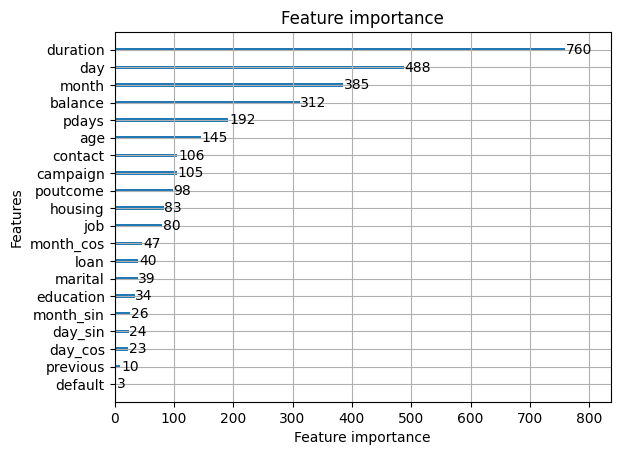

In [91]:
lgb.plot_importance(base_model)

## Bayes Search with 10-fold CV

In [104]:
kf = KFold(n_splits = 10, shuffle = True, random_state = RANDOM_STATE)        # Construct a 10-fold shuffler
reg = lgb.LGBMClassifier(random_state=RANDOM_STATE)                            # Base estimator
opt = BayesSearchCV(reg,                                                      # Param Space
                    {
                        "max_depth": Integer(3, 13),
                        "num_leaves": Integer(20, 200),
                        "min_child_samples": Integer(7, 75),
                        "colsample_bytree": Real(0.25, 1),
                        "subsample": Real(0.25, 1),
                        "subsample_freq": Integer(1, 50),
                        "reg_alpha": Real(0, 1),
                        "reg_lambda": Real(0, 1),
                        "min_split_gain": Real(0, 0.5)
                    },
                    n_iter = 150,
                    cv = kf,
                    n_jobs = 3,
                    random_state = RANDOM_STATE,
                    fit_params={"eval_metric": 'auc',
                                "categorical_feature": cat_features + bool_features + ['month', 'day'], 
                                'feature_name': X_train_encoded.columns.to_list()},         # Passing categorical features to LGBMClassifier
                    verbose=2
                   )
opt

,estimator,LGBMClassifie...state=1048576)
,search_spaces,"{'colsample_bytree': Real(low=0.25...rm='identity'), 'max_depth': Integer(low=3...rm='identity'), 'min_child_samples': Integer(low=7...rm='identity'), 'min_split_gain': Real(low=0, h...rm='identity'), ...}"
,optimizer_kwargs,None
,n_iter,150
,scoring,None
,fit_params,"{'categorical_feature': ['job', 'marital', ...], 'eval_metric': 'auc', 'feature_name': ['job', 'marital', ...]}"
,n_jobs,3
,n_points,1
,iid,'deprecated'
,refit,True
,cv,KFold(n_split... shuffle=True)


In [105]:
from joblib import parallel_backend

with parallel_backend('threading'):
    opt.fit(X_train_encoded, y_train)

display(opt.best_estimator_)

print(f'Best parameters are {opt.best_params_}')
print(f'Best score is {opt.best_score_}')

Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769515544431, reg_lambda=0.624274461459859, subsample=0.5656782387409611, subsample_freq=31; total time=   6.2s
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769515544431, reg_lambda=0.624274461459859, subsample=0.5656782387409611, subsample_freq=31; total time=   7.8s
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769515544431, reg_lambda=0.624274461459859, subsample=0.5656782387409611, subsample_freq=31; total time=   8.9s
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769

,boosting_type,'gbdt'
,num_leaves,161
,max_depth,13
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,75


Best parameters are OrderedDict({'colsample_bytree': 0.7402569588590497, 'max_depth': 13, 'min_child_samples': 75, 'min_split_gain': 0.0, 'num_leaves': 161, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_freq': 1})
Best score is 0.9364533333333334


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

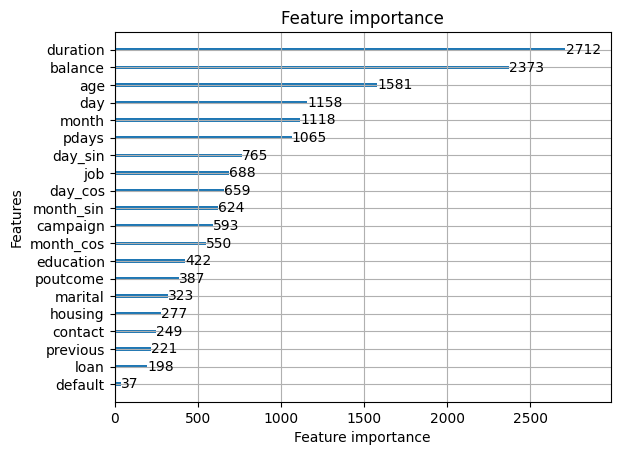

In [106]:
lgb.plot_importance(opt.best_estimator_)

In [107]:
param_dict = opt.best_params_


In [108]:
import joblib

best_lgb = opt.best_estimator_
joblib.dump(best_lgb, 'best_lgb_model.pkl')


# best_lgb = joblib.load('best_lgb_model.pkl')
# best_lgb.fit(X_train_encoded, y_train_dropped)
# best_lgb

['best_lgb_model.pkl']

In [109]:
print(f'Test Score: {roc_auc_score(y_test, best_lgb.predict_proba(X_test_encoded)[:, 1])}')

Test Score: 0.9682686221268705


# Submit Prediction

In [110]:
full_test_csv = pd.read_csv('datasets/test.csv', index_col=0)
full_test_encoded = full_preprocessor.transform(full_test_csv)
full_test_encoded.head()

,job,marital,contact,education,poutcome,default,housing,loan,month,age,balance,day,duration,campaign,pdays,previous,month_sin,month_cos,day_sin,day_cos
id,,,,,,,,,,,,,,,,,,,,
750000,1.0,1.0,NaN,1.0,NaN,0.0,1.0,0.0,4.0,32,1397,21,224,1,-1,0,8.660254e-01,-5.000000e-01,-0.897805,-0.440394
750001,4.0,1.0,0.0,2.0,NaN,0.0,1.0,0.0,3.0,44,23,3,586,2,-1,0,1.000000e+00,6.123234e-17,0.571268,0.820763
750002,6.0,1.0,0.0,0.0,NaN,0.0,1.0,1.0,4.0,36,46,13,111,2,-1,0,8.660254e-01,-5.000000e-01,0.485302,-0.874347
750003,1.0,1.0,NaN,1.0,NaN,0.0,1.0,1.0,4.0,58,-1380,29,125,1,-1,0,8.660254e-01,-5.000000e-01,-0.394356,0.918958
750004,9.0,2.0,0.0,1.0,NaN,0.0,1.0,0.0,6.0,28,1950,22,181,1,-1,0,1.224647e-16,-1.000000e+00,-0.968077,-0.250653


## Base Model

In [83]:
y_pred_proba = base_model.predict_proba(full_test_encoded)[:, 1]

In [84]:
submission = pd.read_csv('datasets/sample_submission.csv', index_col=0)
print(submission.head())
submission[TARGET] = y_pred_proba
print('\n')
print(submission.head())
submission.to_csv('datasets/submission_LGBM_base.csv')
print('Result saved successfully!')

          y
id         
750000  0.5
750001  0.5
750002  0.5
750003  0.5
750004  0.5


               y
id              
750000  0.004865
750001  0.150682
750002  0.001011
750003  0.000420
750004  0.018093
Result saved successfully!


## Best LGB Classifier

In [111]:
y_pred_proba = best_lgb.predict_proba(full_test_encoded)

In [112]:
submission = pd.read_csv('datasets/sample_submission.csv', index_col=0)
print(submission.head())
submission[TARGET] = y_pred_proba[:, 1]
print('\n')
print(submission.head())
submission.to_csv('datasets/submission_LGBM_Bayes.csv')
print('Result saved successfully!')

          y
id         
750000  0.5
750001  0.5
750002  0.5
750003  0.5
750004  0.5


               y
id              
750000  0.003527
750001  0.104955
750002  0.000455
750003  0.000193
750004  0.009235
Result saved successfully!
